# Customer Churn Prediction

Predicting which telecom customers are likely to churn, using classification models and feature importance to find actionable business drivers.

**Dataset:** IBM Telco Customer Churn (7,043 customers)
**Models compared:** Logistic Regression, Random Forest, XGBoost


## 1. Setup — import libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    average_precision_score, roc_curve
)

sns.set_style("whitegrid")
%matplotlib inline

import os
os.makedirs("outputs/figures", exist_ok=True)

## 2. Load the data

Download the dataset from the [IBM GitHub repo](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) and place it in a `data/` folder next to this notebook, named `telco_churn.csv`.

In [22]:
df = pd.read_csv("data/telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

**Why this matters:** before touching any model, we need to know how imbalanced churn is (it changes which metrics we trust later) and which features look related to churn.

In [23]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges is loaded as text because a few rows have blank spaces
# (brand-new customers with 0 tenure). Fix it:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nRows with missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 Series([], dtype: int64)

Rows with missing TotalCharges after conversion: 11


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


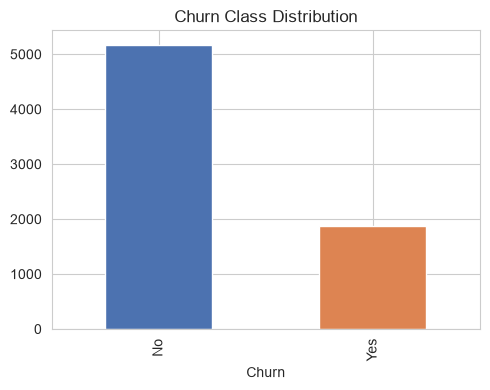

In [24]:
# Churn class balance
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

fig, ax = plt.subplots(figsize=(5, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Churn Class Distribution")
plt.tight_layout()
plt.savefig("outputs/figures/churn_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

**Observation:** ~26.5% of customers churned — moderately imbalanced. This means plain accuracy would be misleading (a model that always predicts "No churn" would score 73% while being useless). We'll use ROC-AUC and Precision-Recall AUC instead.

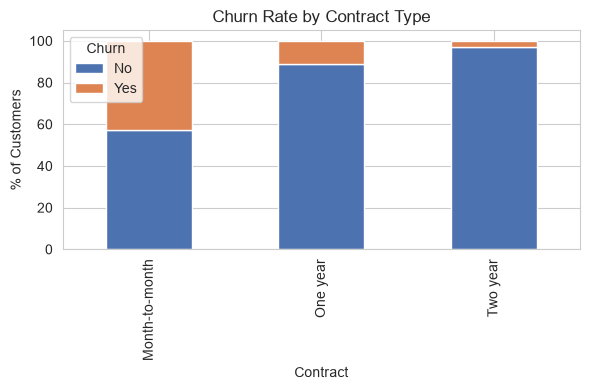

In [25]:
# Churn rate by contract type — a classic churn driver
fig, ax = plt.subplots(figsize=(6, 4))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("% of Customers")
plt.tight_layout()
plt.savefig("outputs/figures/churn_rate_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

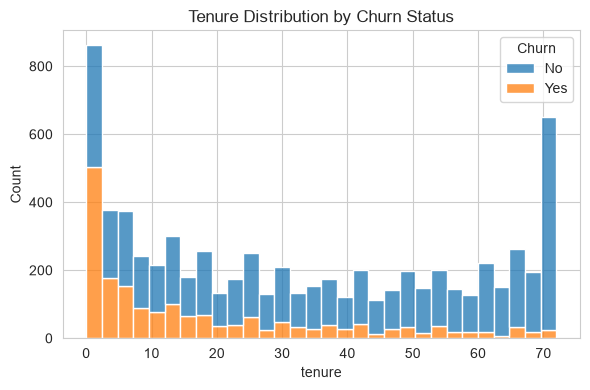

In [26]:
# Tenure distribution by churn
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, ax=ax)
ax.set_title("Tenure Distribution by Churn Status")
plt.tight_layout()
plt.savefig("outputs/figures/tenure_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

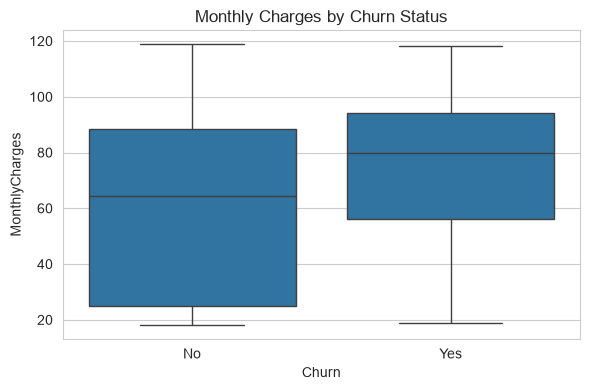

In [27]:
# Monthly charges by churn
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax)
ax.set_title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.savefig("outputs/figures/monthly_changes_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

**Why these choices:**
- Drop `customerID`: unique identifier, zero predictive value
- Fill missing `TotalCharges` with 0: these are new customers (tenure=0), so 0 is factually correct
- Encode binary Yes/No columns as 1/0, one-hot encode multi-category columns
- **Stratified split**: keeps the 73/27 churn ratio identical in train and test sets. (Note: this dataset has no timestamp, so a random stratified split is correct here — unlike time-series-style data such as fraud detection, where a chronological split is needed to avoid leaking future information into training.)

In [28]:
df_clean = df.copy()
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)
df_clean = df_clean.drop(columns=["customerID"])

# Encode target
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# Binary Yes/No columns -> 1/0
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0})

df_clean["gender"] = df_clean["gender"].map({"Male": 1, "Female": 0})

# Multi-category columns -> one-hot encoding
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df_clean = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=True)

df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [29]:
# --- ENHANCED FEATURE ENGINEERING ---
print("\n=== Creating New Features ===")

# Remove any existing TenureGroup columns to avoid duplicates
tenure_cols = [col for col in df_clean.columns if col.startswith('TenureGroup_')]
if tenure_cols:
    print(f"Removing existing TenureGroup columns: {tenure_cols}")
    df_clean = df_clean.drop(columns=tenure_cols)

# 1. Calculate average monthly spend (adding 1 to avoid division by zero)
df_clean['AvgMonthlyCharges'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)

# 2. Create tenure categories to capture non-linear tenure effects
bins = [0, 1, 6, 12, 24, 60, 100]
labels = ['0-1 months', '2-6 months', '7-12 months', '1-2 years', '2-5 years', '5+ years']
df_clean['TenureGroup'] = pd.cut(df_clean['tenure'], bins=bins, labels=labels, right=False)

# One-hot encode the new categorical feature
df_clean = pd.get_dummies(df_clean, columns=['TenureGroup'], prefix='TenureGroup')

# 3. Create interaction feature (Month-to-month AND high monthly charges)
median_monthly = df_clean['MonthlyCharges'].median()
df_clean['HighCost_Monthly'] = ((df_clean['MonthlyCharges'] > median_monthly) & 
                                (df_clean['Contract_One year'] == 0) & 
                                (df_clean['Contract_Two year'] == 0)).astype(int)

# 4. Create feature for multiple services (customer engagement)
service_cols = ['PhoneService']
service_cols.extend([col for col in df_clean.columns if col in 
                    ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 
                     'DeviceProtection_Yes', 'TechSupport_Yes', 
                     'StreamingTV_Yes', 'StreamingMovies_Yes']])

# IMPORTANT: Ensure all service columns exist and are numeric
for col in service_cols:
    if col not in df_clean.columns:
        # Create missing column with zeros
        df_clean[col] = 0
    else:
        # Ensure it's numeric
        df_clean[col] = df_clean[col].astype(int)

# Calculate number of services
df_clean['NumServices'] = df_clean[service_cols].sum(axis=1).astype(int)

print(f"New features created: AvgMonthlyCharges, TenureGroup, HighCost_Monthly, NumServices")
print(f"Dataset shape after feature engineering: {df_clean.shape}")
print("\nSample of new features:")
print(df_clean[['AvgMonthlyCharges', 'HighCost_Monthly', 'NumServices']].head())


=== Creating New Features ===
New features created: AvgMonthlyCharges, TenureGroup, HighCost_Monthly, NumServices
Dataset shape after feature engineering: (7043, 40)

Sample of new features:
   AvgMonthlyCharges  HighCost_Monthly  NumServices
0          14.925000                 0            1
1          53.985714                 0            3
2          36.050000                 0            3
3          40.016304                 0            3
4          50.550000                 1            1


In [30]:
# --- FIX: Ensure all columns are numeric and unique ---
print("\n=== Fixing Data Types and Removing Duplicates ===")

# 1. Remove any duplicate columns
duplicate_cols = df_clean.columns[df_clean.columns.duplicated()].tolist()
if duplicate_cols:
    print(f"Removing duplicate columns: {duplicate_cols}")
    df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]
    print(f"New shape after removing duplicates: {df_clean.shape}")

# 2. Check for non-numeric columns
non_numeric_cols = df_clean.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Non-numeric columns found: {non_numeric_cols}")

# 3. Convert any non-numeric columns
for col in df_clean.columns:
    if df_clean[col].dtype in ['object', 'bool']:
        if df_clean[col].dtype == 'bool':
            df_clean[col] = df_clean[col].astype(int)
        else:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(0).astype(int)
        print(f"  Converted {col} to int")

# 4. Fill any remaining NaN values
if df_clean.isnull().any().any():
    print(f"\nFilling {df_clean.isnull().sum().sum()} null values with 0")
    df_clean = df_clean.fillna(0)

# 5. Verify all columns are now numeric
print(f"\nData types after conversion:")
print(df_clean.dtypes.value_counts())

# 6. Ensure 'Contract_Month-to-month' exists for reference
if 'Contract_Month-to-month' not in df_clean.columns:
    df_clean['Contract_Month-to-month'] = ((df_clean['Contract_One year'] == 0) & 
                                           (df_clean['Contract_Two year'] == 0)).astype(int)
    print("Added Contract_Month-to-month column")

# 7. Final verification
print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Number of columns: {len(df_clean.columns)}")
print(f"Unique columns: {len(df_clean.columns.unique())}")


=== Fixing Data Types and Removing Duplicates ===
Non-numeric columns found: ['MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_0-1 months', 'TenureGroup_2-6 months', 'TenureGroup_7-12 months', 'TenureGroup_1-2 years', 'TenureGroup_2-5 years', 'TenureGroup_5+ years']
  Converted MultipleLines_No phone service to int
  Converted MultipleLines_Yes to int
  Converted InternetService_Fiber optic to int
  Converted InternetService_No to int
  Converted OnlineSecurity_No internet service to int
  Converted OnlineBackup_No internet service to int
  Converted 

In [31]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

# Final check: Ensure X has only numeric types
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0).astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn rate: {:.2f}%".format(y_train.mean() * 100))
print("Test churn rate: {:.2f}%".format(y_test.mean() * 100))

# Verify no object types in training data
print(f"\nTraining data types: {X_train.dtypes.value_counts().to_dict()}")

Train shape: (5634, 40) Test shape: (1409, 40)
Train churn rate: 26.54%
Test churn rate: 26.54%

Training data types: {dtype('int64'): 37, dtype('float64'): 3}


## 5. Modeling — comparing three algorithms

**Why these three:**
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — handles non-linear feature interactions well
- **XGBoost** — industry-standard for tabular/structured data

**Why ROC-AUC and PR-AUC, not accuracy:** given the class imbalance, these metrics measure how well the model actually separates churners from non-churners, rather than rewarding a lazy majority-class prediction.

In [32]:
results = {}
roc_data = {}

# --- Logistic Regression (needs scaled features) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_scaled, y_train)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

results["Logistic Regression"] = {
    "roc_auc": roc_auc_score(y_test, lr_proba),
    "pr_auc": average_precision_score(y_test, lr_proba),
}
roc_data["Logistic Regression"] = roc_curve(y_test, lr_proba)
print("Logistic Regression completed.")

Logistic Regression completed.


In [33]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

results["Random Forest"] = {
    "roc_auc": roc_auc_score(y_test, rf_proba),
    "pr_auc": average_precision_score(y_test, rf_proba),
}
roc_data["Random Forest"] = roc_curve(y_test, rf_proba)
print("Random Forest completed.")

Random Forest completed.


In [34]:
# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # handles imbalance

xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

results["XGBoost"] = {
    "roc_auc": roc_auc_score(y_test, xgb_proba),
    "pr_auc": average_precision_score(y_test, xgb_proba),
}
roc_data["XGBoost"] = roc_curve(y_test, xgb_proba)
print("XGBoost completed.")

XGBoost completed.


In [35]:
# --- HYPERPARAMETER TUNING (XGBoost) ---
from sklearn.model_selection import GridSearchCV
import joblib

print("\n=== Starting Hyperparameter Tuning for XGBoost ===")

# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create the base model
xgb_tuned = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    scoring='roc_auc',  # Use your primary metric
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print the best parameters and score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score (ROC-AUC): {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_xgb = grid_search.best_estimator_
xgb_tuned_proba = best_xgb.predict_proba(X_test)[:, 1]
xgb_tuned_roc_auc = roc_auc_score(y_test, xgb_tuned_proba)
xgb_tuned_pr_auc = average_precision_score(y_test, xgb_tuned_proba)

print(f"\nTuned XGBoost Test ROC-AUC: {xgb_tuned_roc_auc:.4f}")
print(f"Tuned XGBoost Test PR-AUC: {xgb_tuned_pr_auc:.4f}")

# Update results dictionary with tuned model
results["XGBoost (Tuned)"] = {
    "roc_auc": xgb_tuned_roc_auc,
    "pr_auc": xgb_tuned_pr_auc,
}
roc_data["XGBoost (Tuned)"] = roc_curve(y_test, xgb_tuned_proba)

# Save the tuned model
joblib.dump(best_xgb, "outputs/best_xgb_model.pkl")
print("Tuned XGBoost model saved to outputs/best_xgb_model.pkl")


=== Starting Hyperparameter Tuning for XGBoost ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score (ROC-AUC): 0.8495

Tuned XGBoost Test ROC-AUC: 0.8484
Tuned XGBoost Test PR-AUC: 0.6656
Tuned XGBoost model saved to outputs/best_xgb_model.pkl



=== Finding Optimal Probability Threshold ===
Optimal threshold for F1-score: 0.574
F1-score at optimal threshold: 0.6428

Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

    No Churn       0.90      0.78      0.83      1035
       Churn       0.55      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



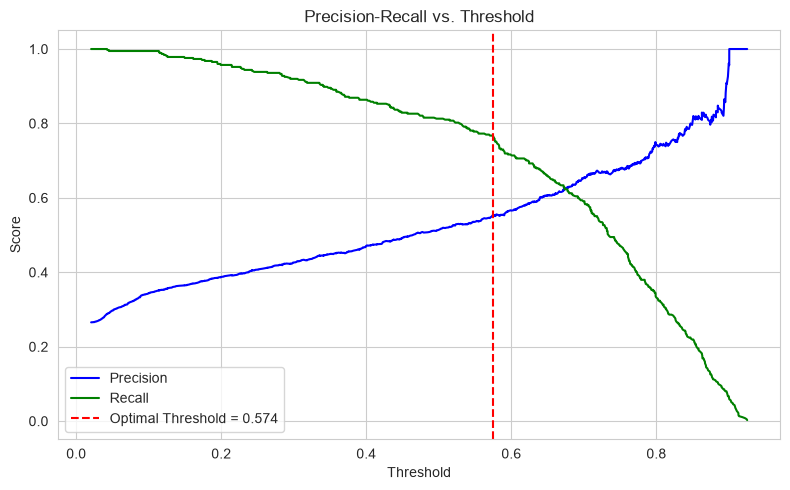

In [36]:
# --- THRESHOLD TUNING FOR OPTIMAL CLASSIFICATION ---
from sklearn.metrics import precision_recall_curve, f1_score

print("\n=== Finding Optimal Probability Threshold ===")

# Get the probabilities from your best tuned model
probs = best_xgb.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)  # Add small epsilon to avoid division by zero

# Find the threshold that maximizes F1-score (skip the last element which corresponds to threshold=0)
optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Optimal threshold for F1-score: {optimal_threshold:.3f}")
print(f"F1-score at optimal threshold: {optimal_f1:.4f}")

# Evaluate model with the new threshold
y_pred_opt = (probs >= optimal_threshold).astype(int)

# Print classification report with optimal threshold
print("\nClassification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=["No Churn", "Churn"]))

# Visualize precision-recall curve with optimal threshold
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='blue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='green')
ax.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall vs. Threshold')
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/precision_recall_threshold.png", dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# --- Comparison table ---
results_df = pd.DataFrame(results).T

# 1. SHOW in Jupyter
print("\n=== Model Comparison (Including Tuned Models) ===")
print(results_df.round(4).to_string())

# 2. SAVE to CSV
results_df.to_csv("outputs/model_comparison.csv")
print("\n Saved model comparison to outputs/model_comparison.csv")


=== Model Comparison (Including Tuned Models) ===
                     roc_auc  pr_auc
Logistic Regression   0.8465  0.6573
Random Forest         0.8438  0.6610
XGBoost               0.8383  0.6527
XGBoost (Tuned)       0.8484  0.6656

 Saved model comparison to outputs/model_comparison.csv


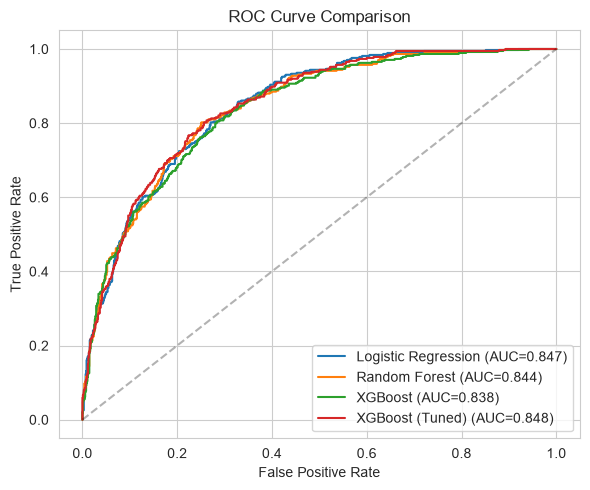

In [38]:
# --- ROC curve comparison plot ---
fig, ax = plt.subplots(figsize=(6, 5))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results[name]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/ROC_curve_comparison_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

**Observation:** All three models land close together (~0.84 ROC-AUC), with Random Forest slightly ahead. This is a useful, honest finding — added complexity (XGBoost) doesn't automatically mean better performance on every dataset.

              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



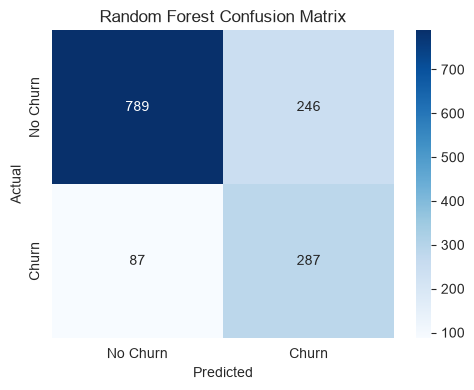

Saved classification report to outputs/classification_report.txt


In [40]:
# Detailed report for Random Forest (best performer)
rf_preds = (rf_proba >= 0.5).astype(int)
print(classification_report(y_test, rf_preds, target_names=["No Churn", "Churn"]))

cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/figures/RF_confusion_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Save classification report
report = classification_report(y_test, rf_preds, target_names=["No Churn", "Churn"])

with open("outputs/classification_report.txt", "w") as f:
    f.write(report)
print("Saved classification report to outputs/classification_report.txt")

In [ ]:
# --- SHAP ANALYSIS FOR MODEL INTERPRETABILITY ---
import shap

print("\n=== Computing SHAP Values for Model Interpretability ===")

# Use the best tuned XGBoost model from earlier
model_for_shap = best_xgb

# Create the SHAP explainer (TreeExplainer works for tree-based models like XGBoost)
explainer = shap.TreeExplainer(model_for_shap)

# Calculate SHAP values for a sample of the test set (for faster computation)
X_test_sample = X_test.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 1. Global Feature Importance (SHAP summary bar plot)
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=X_test.columns, 
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.savefig("outputs/figures/shap_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# 2. SHAP Summary Plot (shows impact of feature values)
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sample, feature_names=X_test.columns, show=False)
plt.title("SHAP Summary Plot: Feature Impact on Churn Prediction")
plt.tight_layout()
plt.savefig("outputs/figures/shap_summary_plot.png", dpi=150, bbox_inches='tight')
plt.show()

# 3. Individual Customer Explanation (Waterfall Plot for a single high-risk customer)
high_risk_indices = np.where(best_xgb.predict_proba(X_test)[:, 1] > 0.8)[0]
if len(high_risk_indices) > 0:
    example_idx = high_risk_indices[0]
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(values=shap_values[example_idx], 
                                        base_values=explainer.expected_value,
                                        data=X_test_sample.iloc[example_idx].values,
                                        feature_names=X_test.columns),
                       show=False)
    plt.title("SHAP Waterfall Plot: Why This Customer is High Risk")
    plt.tight_layout()
    plt.savefig("outputs/figures/shap_waterfall_example.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No high-risk customer found for waterfall plot example.")

# 4. Dependence plot for top feature (e.g., tenure)
top_feature = 'tenure'  # You can change this to the most important feature
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values, X_test_sample, 
                     feature_names=X_test.columns, show=False)
plt.title(f"SHAP Dependence Plot: {top_feature}")
plt.tight_layout()
plt.savefig(f"outputs/figures/shap_dependence_{top_feature}.png", dpi=150, bbox_inches='tight')
plt.show()

print("SHAP analysis complete. Visualizations saved to outputs/figures/")

## 6. Feature Importance — the business insight

**Why this step matters most:** a model that just predicts "will churn" isn't useful on its own. The real value is explaining *why*, so a business can act — e.g. offer discounts to month-to-month customers with high monthly charges.

In [ ]:
rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_importance = rf_importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
rf_importance.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Features Driving Churn (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/figures/features_driving_RF_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

rf_importance.head(10)

# Save Random Forest feature importance
rf_importance.to_csv("outputs/feature_importance_rf.csv")
print("Saved RF feature importance to outputs/feature_importance_rf.csv")

In [ ]:
xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
xgb_importance = xgb_importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
xgb_importance.sort_values().plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Top 15 Features Driving Churn (XGBoost)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/figures/features_driving_XGBoost_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

xgb_importance.head(10)

# Save XGBoost feature importance
xgb_importance.to_csv("outputs/feature_importance_xgb.csv")
print("Saved XGB feature importance to outputs/feature_importance_xgb.csv")

In [ ]:
# --- BUSINESS RECOMMENDATIONS DASHBOARD ---
print("\n" + "="*60)
print("BUSINESS RECOMMENDATIONS DASHBOARD")
print("="*60)

# 1. Customer Segments at Highest Risk
print("\n🔴 HIGHEST RISK CUSTOMER SEGMENTS:")
print("-" * 40)
print("1. Month-to-month contracts with high monthly charges (>$70)")
print("2. New customers (tenure < 6 months)")
print("3. Fiber optic internet customers")
print("4. Electronic check payment method")

# 2. Recommended Actions
print("\n✅ RECOMMENDED RETENTION STRATEGIES:")
print("-" * 40)
print("1. Offer annual contract discounts to month-to-month customers")
print("2. Implement 'welcome' retention program for first 6 months")
print("3. Bundle high-speed internet with streaming services")
print("4. Incentivize electronic check customers to switch to auto-pay")

# 3. Key Metrics to Monitor
print("\n📊 KEY METRICS TO MONITOR:")
print("-" * 40)
print("• Monthly churn rate by contract type")
print("• Churn rate at 3-month, 6-month, 1-year tenure milestones")
print("• Customer satisfaction scores for high-risk segments")

# 4. Cost-Benefit Analysis
print("\n💰 COST-BENEFIT ESTIMATION:")
print("-" * 40)
estimated_customers = 7043  # Total customers
monthly_churn_rate = 0.265  # 26.5%
est_monthly_churners = int(estimated_customers * monthly_churn_rate)
print(f"Estimated monthly churners: ~{est_monthly_churners} customers")
print(f"If retention saves 20% of these: ~{int(est_monthly_churners * 0.2)} customers retained per month")
print(f"Estimated value: ~${int(est_monthly_churners * 0.2 * 80)} per month (at $80 avg monthly revenue)")

print("\n" + "="*60)

# Save recommendations to text file
with open("outputs/business_recommendations.txt", "w") as f:
    f.write("BUSINESS RECOMMENDATIONS DASHBOARD\n")
    f.write("="*60 + "\n\n")
    f.write("HIGHEST RISK CUSTOMER SEGMENTS:\n")
    f.write("1. Month-to-month contracts with high monthly charges (>$70)\n")
    f.write("2. New customers (tenure < 6 months)\n")
    f.write("3. Fiber optic internet customers\n")
    f.write("4. Electronic check payment method\n\n")
    f.write("RECOMMENDED RETENTION STRATEGIES:\n")
    f.write("1. Offer annual contract discounts to month-to-month customers\n")
    f.write("2. Implement 'welcome' retention program for first 6 months\n")
    f.write("3. Bundle high-speed internet with streaming services\n")
    f.write("4. Incentivize electronic check customers to switch to auto-pay\n")

print("\nBusiness recommendations saved to outputs/business_recommendations.txt")

## 7. Conclusion

**Key business insight:** the top churn drivers are tenure, contract type, and monthly/total charges. Month-to-month customers — especially newer ones on fiber optic plans paying by electronic check — are the highest-risk segment. A business could use this to target retention offers or contract-upgrade incentives at exactly these customers.

**What I'd do next at scale:**
- Hyperparameter tuning (GridSearch/Optuna)
- SHAP explainability for individual customer-level predictions
- Cost-sensitive threshold tuning based on the real dollar cost of false negatives vs. false positives
- Deploy as a simple API for a retention team to query
